In [1]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.cuda.is_available())

from pathlib import Path
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

Path("probe_checkpoints/reading_probe").mkdir(parents=True, exist_ok=True)
Path("probe_checkpoints/controlling_probe").mkdir(parents=True, exist_ok=True)

/local/rkawaka1/conda/envs/talktuner-gpu/bin/python
2.4.1+cu121
True


In [2]:
import os
from pathlib import Path
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
import torch.nn.functional as F
from losses import edl_mse_loss

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from tqdm.auto import tqdm

from dataset import TextDataset 
from losses import edl_mse_loss

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

from probes import ProbeClassification, ProbeClassificationMixScaler
from train_test_utils import train, test 
import torch.nn as nn

import time

tic, toc = (time.time, time.time)

REPO_ROOT = Path("/local/rkawaka1/TalkTuner-chatbot-llm-dashboard")
DATASET_ROOT = REPO_ROOT / "dataset"

/local/rkawaka1/conda/envs/talktuner-gpu/lib/python3.9/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
## TODO: change ifwe use another model
torch.cuda.empty_cache()

## For Llama2-7B 
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf", use_auth_token=True)
# model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf", use_auth_token=True)
# model.half().cuda()
# model.eval()

## For Gemma-3n-E2B-it
# model_id = "google/gemma-3n-E2B-it"
# tokenizer = AutoTokenizer.from_pretrained(model_id)
# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16,   # or torch.bfloat16 if supported cleanly on that setup
#     low_cpu_mem_usage=True
# )
# model = model.to("cuda")
# model.eval()

## For 

model_name = "Qwen/Qwen2.5-7B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


In [4]:
from src.probes import ProbeClassification, ProbeClassificationMixScaler
    
class TrainerConfig:
    # optimization parameters
    learning_rate = 1e-3
    betas = (0.9, 0.95)
    weight_decay = 0.1 # only applied on matmul weights
    # learning rate decay params: linear warmup followed by cosine decay to 10% of original
    # checkpoint settings

    def __init__(self, **kwargs):
        for k,v in kwargs.items():
            setattr(self, k, v)

## Linear Probing on All Attributes

In [5]:
import os
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
import torch.nn.functional as F

import torch
from tqdm.auto import tqdm
from src.dataset import split_conversation, llama_v2_prompt, TextDataset

### Reading Probes

  0%|          | 0/4000 [00:00<?, ?it/s]

Corrupted file at /local/rkawaka1/TalkTuner-chatbot-llm-dashboard/dataset/openai_age_2/conversation_650_age_adolescent.txt
Corrupted file at /local/rkawaka1/TalkTuner-chatbot-llm-dashboard/dataset/openai_age_2/conversation_740_age_child.txt
Corrupted file at /local/rkawaka1/TalkTuner-chatbot-llm-dashboard/dataset/openai_age_2/conversation_735_age_older adult.txt
3997
/local/rkawaka1/TalkTuner-chatbot-llm-dashboard/dataset/llama_age_1/conversation_135_age_adult.txt
torch.Size([29, 3584])
2


  0%|          | 0/29 [00:00<?, ?it/s]

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 0----------------------------------------

Train set: Average loss: 0.5939 (0.686 sec) Accuracy: 0.253

Test set: Average loss: 0.5940,  Accuracy: 0.251



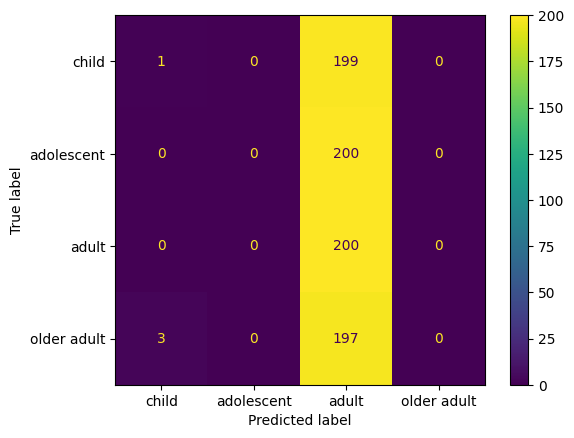

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 1----------------------------------------

Train set: Average loss: 0.5415 (0.668 sec) Accuracy: 0.759

Test set: Average loss: 0.5411,  Accuracy: 0.769



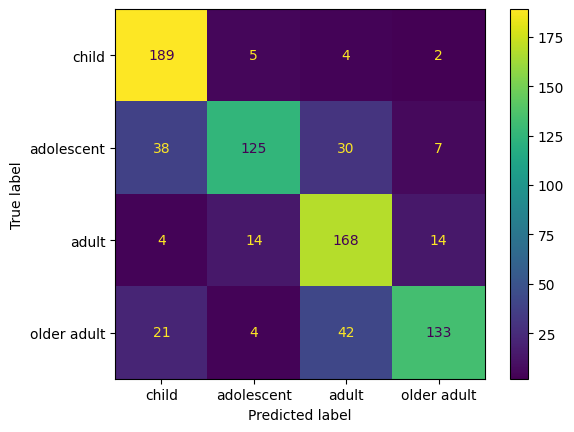

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 2----------------------------------------

Train set: Average loss: 0.5232 (0.665 sec) Accuracy: 0.774

Test set: Average loss: 0.5226,  Accuracy: 0.779



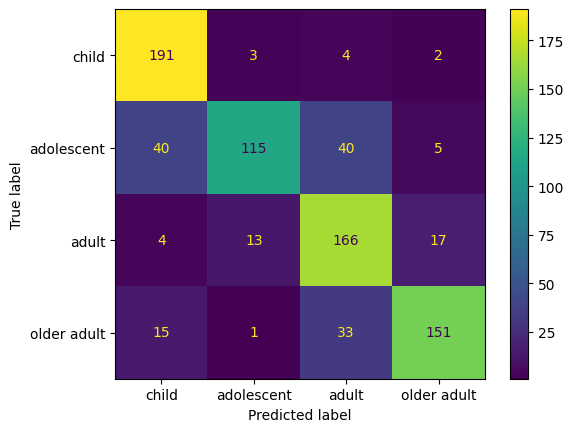

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 3----------------------------------------

Train set: Average loss: 0.4949 (0.679 sec) Accuracy: 0.801

Test set: Average loss: 0.4939,  Accuracy: 0.804



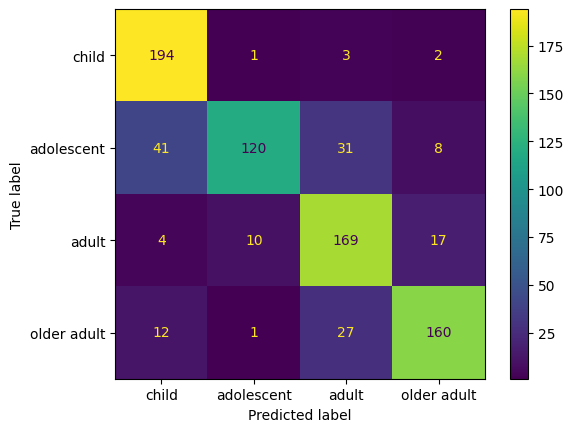

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 4----------------------------------------

Train set: Average loss: 0.4623 (0.673 sec) Accuracy: 0.808

Test set: Average loss: 0.4626,  Accuracy: 0.805



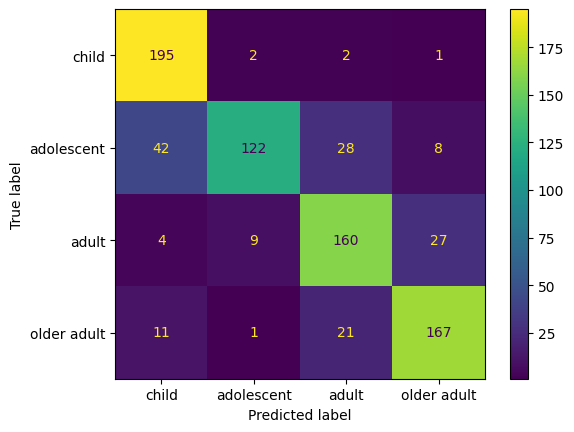

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 5----------------------------------------

Train set: Average loss: 0.3897 (0.680 sec) Accuracy: 0.835

Test set: Average loss: 0.3948,  Accuracy: 0.819



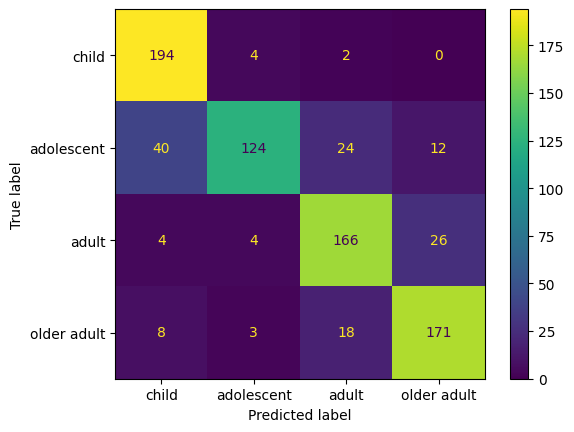

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 6----------------------------------------

Train set: Average loss: 0.3650 (0.669 sec) Accuracy: 0.843

Test set: Average loss: 0.3700,  Accuracy: 0.826



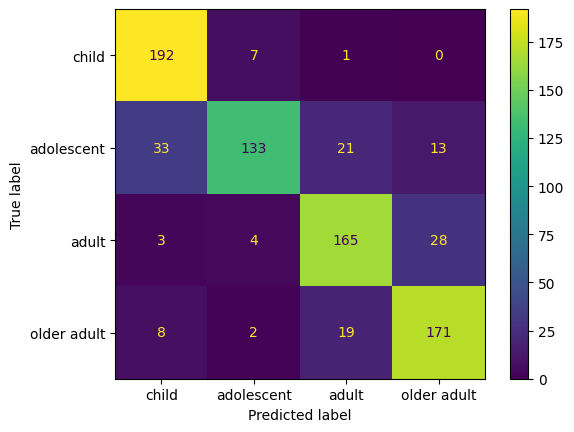

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 7----------------------------------------

Train set: Average loss: 0.3166 (0.684 sec) Accuracy: 0.843

Test set: Average loss: 0.3216,  Accuracy: 0.853



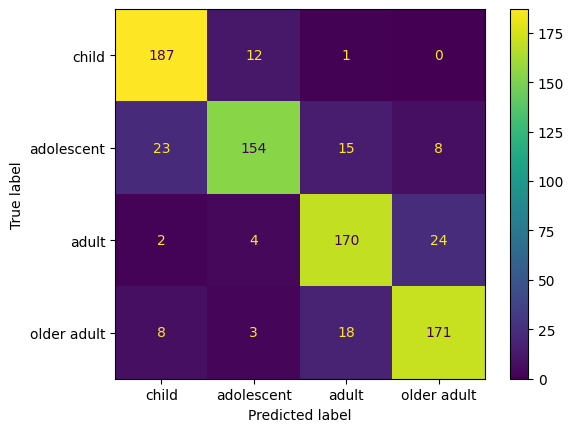

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 8----------------------------------------

Train set: Average loss: 0.2805 (0.677 sec) Accuracy: 0.854

Test set: Average loss: 0.2868,  Accuracy: 0.846



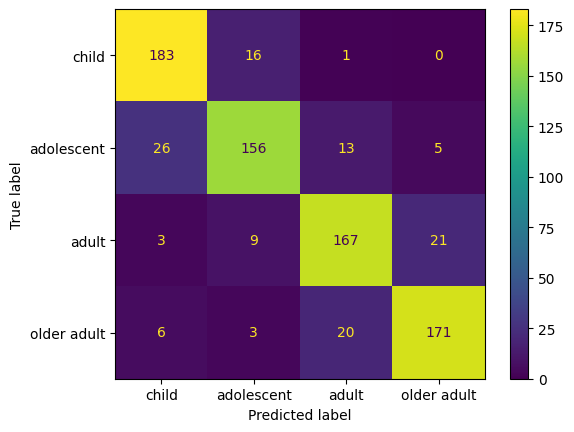

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 9----------------------------------------

Train set: Average loss: 0.2517 (0.680 sec) Accuracy: 0.878

Test set: Average loss: 0.2559,  Accuracy: 0.870



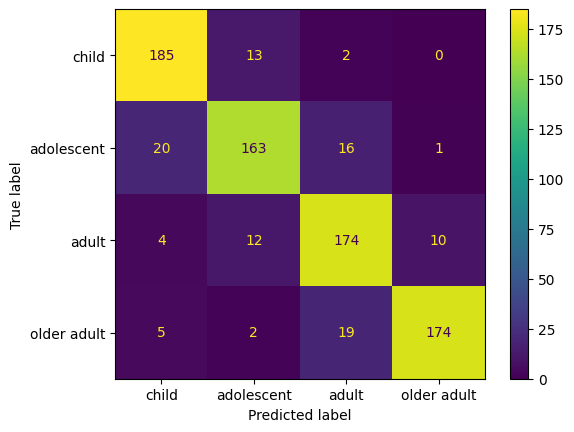

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 10----------------------------------------

Train set: Average loss: 0.2586 (0.682 sec) Accuracy: 0.881

Test set: Average loss: 0.2605,  Accuracy: 0.884



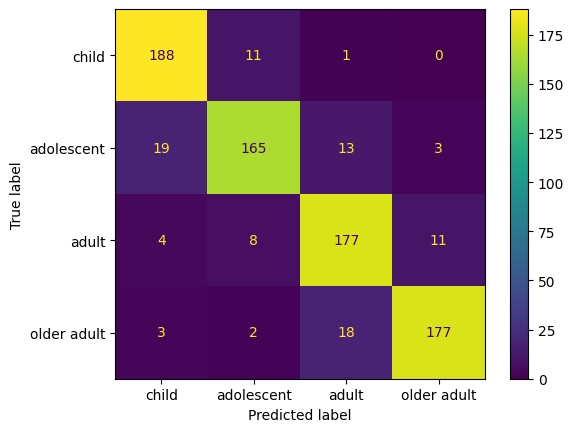

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 11----------------------------------------

Train set: Average loss: 0.2533 (0.675 sec) Accuracy: 0.886

Test set: Average loss: 0.2552,  Accuracy: 0.887



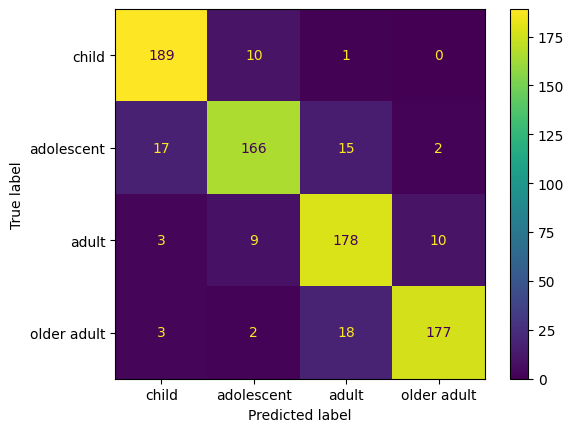

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 12----------------------------------------

Train set: Average loss: 0.2349 (0.667 sec) Accuracy: 0.898

Test set: Average loss: 0.2367,  Accuracy: 0.897



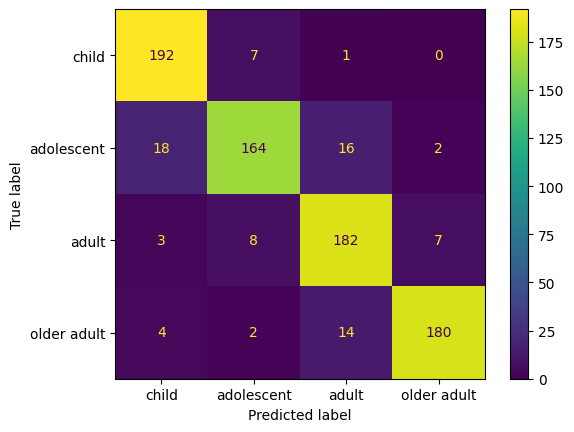

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 13----------------------------------------

Train set: Average loss: 0.2267 (0.684 sec) Accuracy: 0.903

Test set: Average loss: 0.2278,  Accuracy: 0.906



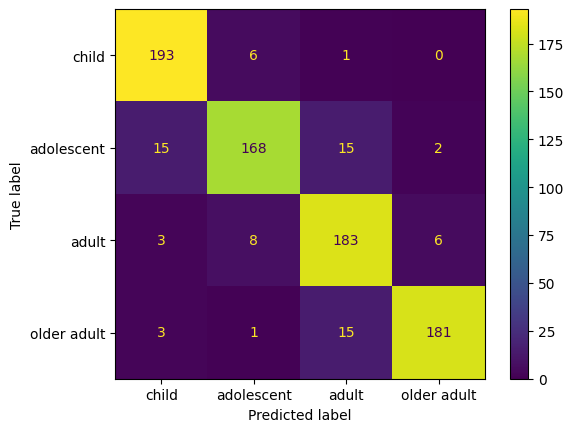

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 14----------------------------------------

Train set: Average loss: 0.2018 (0.673 sec) Accuracy: 0.921

Test set: Average loss: 0.2052,  Accuracy: 0.914



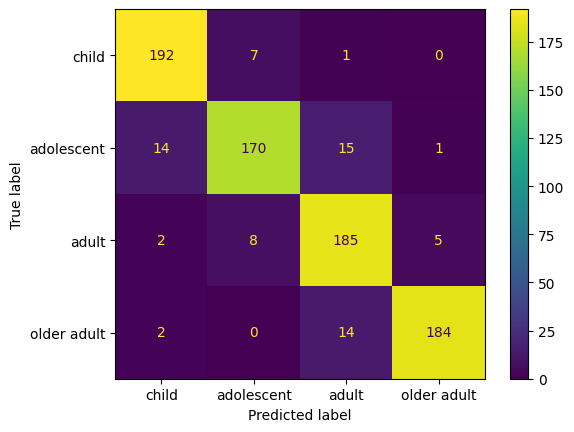

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 15----------------------------------------

Train set: Average loss: 0.1847 (0.667 sec) Accuracy: 0.933

Test set: Average loss: 0.1899,  Accuracy: 0.922



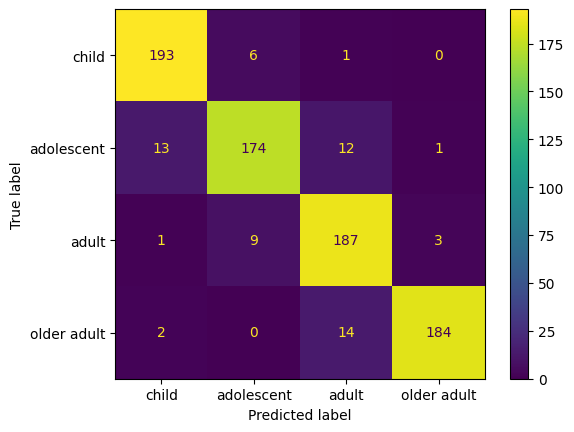

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 16----------------------------------------

Train set: Average loss: 0.1728 (0.692 sec) Accuracy: 0.936

Test set: Average loss: 0.1796,  Accuracy: 0.927



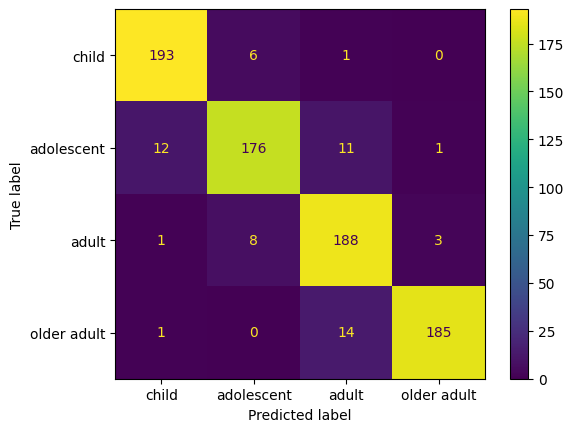

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 17----------------------------------------

Train set: Average loss: 0.1680 (0.671 sec) Accuracy: 0.936

Test set: Average loss: 0.1747,  Accuracy: 0.925



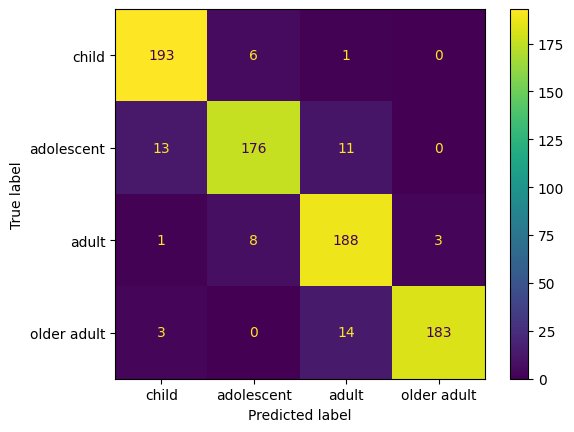

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 18----------------------------------------

Train set: Average loss: 0.1619 (0.674 sec) Accuracy: 0.938

Test set: Average loss: 0.1703,  Accuracy: 0.926



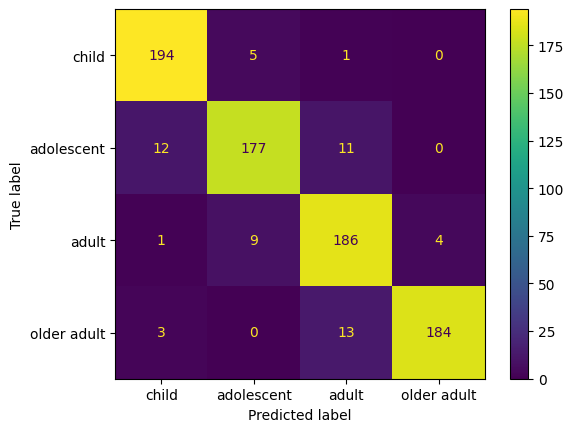

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 19----------------------------------------

Train set: Average loss: 0.1544 (0.664 sec) Accuracy: 0.940

Test set: Average loss: 0.1640,  Accuracy: 0.927



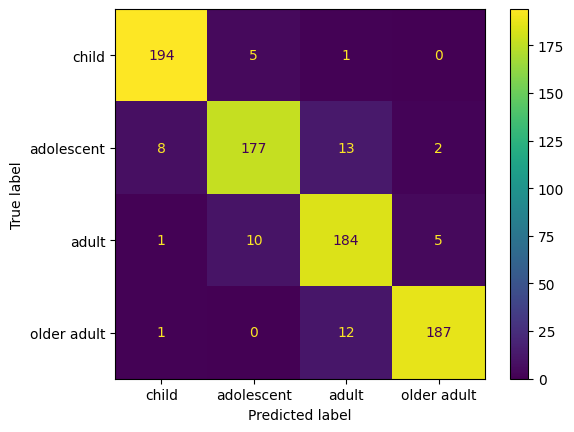

Decayed: {'proj.0.weight', 'proj.0.bias'}
----------------------------------------Layer 20----------------------------------------


In [ ]:
from probes import LinearProbeClassification, LinearProbeClassificationMixScaler
import sklearn.model_selection
import pickle
import random

jump_socioeco = True

new_prompt_format=True
residual_stream=True
uncertainty = False
logistic = True
augmented = False
remove_last_ai_response = True
include_inst = True
one_hot = True

label_to_id_age = {"child": 0,
                   "adolescent": 1,
                   "adult": 2,
                   "older adult": 3,
                  }

label_to_id_gender = {"male": 0,
                      "female": 1,
                     }

label_to_id_socioeconomic = {"low": 0,
                             "middle": 1,
                             "high": 2}

label_to_id_neweducation = {"someschool": 0,
                            "highschool": 1,
                            "collegemore": 2}

prompt_translator = {"_age_": "age",
                     "_gender_": "gender",
                     "_socioeco_": "socioeconomic status",
                     "_education_": "education level",}

openai_dataset = {"_age_": str(DATASET_ROOT / "openai_age_1"),
                  "_gender_": str(DATASET_ROOT / "openai_gender_1"),
                  "_education_": str(DATASET_ROOT / "openai_education_three_classes_1"),
                  "_socioeco_": str(DATASET_ROOT / "openai_socioeconomic_1"),}

accuracy_dict = {}

# directories = [str(DATASET_ROOT / "llama_age_1"), str(DATASET_ROOT / "llama_gender_1"),
#                str(DATASET_ROOT / "llama_socioeconomic_1"), str(DATASET_ROOT / "openai_education_three_classes_1")]

# label_idfs = ["_age_", "_gender_", "_socioeco_", "_education_"]

# label_to_ids = [label_to_id_age, label_to_id_gender,
#                 label_to_id_socioeconomic, label_to_id_neweducation]

directories = [str(DATASET_ROOT / "llama_age_1")]
label_idfs = ["_age_"]
label_to_ids = [label_to_id_age]
torch.cuda.empty_cache()

"""
If you want to train a probe for just specific category such as age, 
modify directories, label_idfds, and label_to_ids. For instance,
directories = [str(DATASET_ROOT / "llama_age_1")]
label_idfs = ["_age_"]
label_to_ids = [label_to_id_age]
"""
for directory, label_idf, label_to_id in zip(directories, label_idfs, label_to_ids):
    if label_idf == "_education_":
        additional_dataset=[]
    else:
        additional_dataset=[directory[:-2] + "_2/", openai_dataset[label_idf]]
    if label_idf == "_gender_":
        additional_dataset += [str(DATASET_ROOT / "openai_gender_2"), str(DATASET_ROOT / "openai_gender_3"), 
                               str(DATASET_ROOT / "openai_gender_4"),]
    if label_idf == "_education_":
        additional_dataset += [str(DATASET_ROOT / "openai_education_three_classes_2"), str(DATASET_ROOT / "openai_education_three_classes_3")]
    if label_idf == "_socioeco_":
        additional_dataset += [str(DATASET_ROOT / "openai_socioeconomic_2")]
    if label_idf == "_age_":
        additional_dataset += [str(DATASET_ROOT / "openai_age_2")]

    ## TODO: Delete after testing
    # additional_dataset = []
    # additional_dataset=[directory[:-2] + "_2/"]
    
    ## For llma, dataset is a list of 41 x 5120 tensors. 
    ## in LLama2 7B, its 33 x 4096 tensors
    ## for Qwen, it's 29 x 3584 tensors
    dataset = TextDataset(directory, tokenizer, model, label_idf=label_idf, label_to_id=label_to_id,
                          convert_to_llama2_format=True, additional_datas=additional_dataset, 
                          new_format=new_prompt_format,
                          residual_stream=residual_stream, if_augmented=augmented, 
                          remove_last_ai_response=remove_last_ai_response, include_inst=include_inst, k=1,
                          one_hot=False, last_tok_pos=-1)
    dict_name = label_idf.strip("_")
    
    ## DEBUG: Check the dataset's label distribution and size
    print(len(dataset))
    sample = dataset[0]
    print(sample["file_path"])
    print(sample["hidden_states"].shape)
    print(sample["age"])
    

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_idx, val_idx = sklearn.model_selection.train_test_split(list(range(len(dataset))), 
                                                                  test_size=test_size,
                                                                  train_size=train_size,
                                                                  random_state=12345,
                                                                  shuffle=True,
                                                                  stratify=dataset.labels,
                                                                 )

    train_dataset = Subset(dataset, train_idx)
    test_dataset = Subset(dataset, val_idx)

    ## create PyTorch data loaders that serve datasets in batches 
    sampler = None
    train_loader = DataLoader(train_dataset, shuffle=True, sampler=sampler, pin_memory=True, batch_size=200, num_workers=1)
    test_loader = DataLoader(test_dataset, shuffle=False, pin_memory=True, batch_size=400, num_workers=1)

    if uncertainty:
        loss_func = edl_mse_loss
    else:
        loss_func = nn.BCELoss()
    torch_device = "cuda"

    # seeds = seeds[:9]
    accuracy_dict[dict_name] = []
    accuracy_dict[dict_name + "_final"] = []
    accuracy_dict[dict_name + "_train"] = []
        
    accs = []
    final_accs = []
    train_accs = []
    
    ## TODO: Check the mdoel's layer counts and input_dim
    for i in tqdm(range(0, 29)):
        # if i < 25:
        #     continue
        
        trainer_config = TrainerConfig()
        probe = LinearProbeClassification(probe_class=len(label_to_id.keys()), device="cuda", input_dim=3584,
                                            logistic=logistic)
        optimizer, scheduler = probe.configure_optimizers(trainer_config)
        best_acc = 0
        max_epoch = 50
        verbosity = False
        layer_num = i
        print("-" * 40 + f"Layer {layer_num}" + "-" * 40)
        for epoch in range(1, max_epoch + 1):
            if epoch == max_epoch:
                verbosity = True
            # Get the train results from training of each epoch
            if uncertainty:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num, 
                                        return_raw_outputs=True, epoch_num=epoch, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler, epoch_num=epoch, num_classes=len(label_to_id.keys()))
            else:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num,
                                        return_raw_outputs=True,
                                        one_hot=one_hot, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler,
                                    one_hot=one_hot, num_classes=len(label_to_id.keys()))

            if test_results[1] > best_acc:
                best_acc = test_results[1]
                torch.save(probe.state_dict(), f"probe_checkpoints/reading_probe/{dict_name}_probe_at_layer_{layer_num}.pth")

            torch.cuda.empty_cache()
        
        torch.save(probe.state_dict(), f"probe_checkpoints/reading_probe/{dict_name}_probe_at_layer_{layer_num}_final.pth")
        
        accs.append(best_acc)
        final_accs.append(test_results[1])
        train_accs.append(train_results[1])
        cm = confusion_matrix(test_results[3], test_results[2])
        cm_display = ConfusionMatrixDisplay(cm, display_labels=label_to_id.keys()).plot()
        plt.show()

        accuracy_dict[dict_name].append(accs)
        accuracy_dict[dict_name + "_final"].append(final_accs)
        accuracy_dict[dict_name + "_train"].append(train_accs)
        
        with open("probe_checkpoints/reading_probe_experiment.pkl", "wb") as outfile:
            pickle.dump(accuracy_dict, outfile)
    
    del dataset, train_dataset, test_dataset, train_loader, test_loader
    torch.cuda.empty_cache()

### Control Probe

In [ ]:
from probes import LinearProbeClassification, LinearProbeClassificationMixScaler
import sklearn.model_selection
import pickle
import random

jump_socioeco = True

new_prompt_format=True
residual_stream=True
uncertainty = False
logistic = True
augmented = False
remove_last_ai_response = True
include_inst = True
one_hot = True

label_to_id_age = {"child": 0,
                   "adolescent": 1,
                   "adult": 2,
                   "older adult": 3,
                  }

label_to_id_gender = {"male": 0,
                      "female": 1,
                     }

label_to_id_socioeconomic = {"low": 0,
                             "middle": 1,
                             "high": 2}

label_to_id_neweducation = {"someschool": 0,
                            "highschool": 1,
                            "collegemore": 2}

prompt_translator = {"_age_": "age",
                     "_gender_": "gender",
                     "_socioeco_": "socioeconomic status",
                     "_education_": "education level",}

openai_dataset = {"_age_": str(DATASET_ROOT / "openai_age_1"),
                  "_gender_": str(DATASET_ROOT / "openai_gender_1"),
                  "_education_": str(DATASET_ROOT / "openai_education_three_classes_1"),
                  "_socioeco_": str(DATASET_ROOT / "openai_socioeconomic_1"),}

accuracy_dict = {}

# directories = [str(DATASET_ROOT / "llama_age_1"), str(DATASET_ROOT / "llama_gender_1"),
#                str(DATASET_ROOT / "llama_socioeconomic_1"), str(DATASET_ROOT / "openai_education_three_classes_1")]

# label_idfs = ["_age_", "_gender_", "_socioeco_", "_education_"]

# label_to_ids = [label_to_id_age, label_to_id_gender,
#                 label_to_id_socioeconomic, label_to_id_neweducation]

directories = [str(DATASET_ROOT / "llama_age_1")]
label_idfs = ["_age_"]
label_to_ids = [label_to_id_age]
torch.cuda.empty_cache()

for directory, label_idf, label_to_id in zip(directories, label_idfs, label_to_ids):
    # additional_dataset=[directory[:-1] + "_additional/"]
    if label_idf == "_education_":
        additional_dataset=[]
    else:
        additional_dataset=[directory[:-2] + "_2/", openai_dataset[label_idf]]
    if label_idf == "_gender_":
        additional_dataset += [str(DATASET_ROOT / "openai_gender_2"), str(DATASET_ROOT / "openai_gender_3"), 
                               str(DATASET_ROOT / "openai_gender_4"),]
    if label_idf == "_education_":
        additional_dataset += [str(DATASET_ROOT / "openai_education_three_classes_2"), str(DATASET_ROOT / "openai_education_three_classes_3")]
    if label_idf == "_socioeco_":
        additional_dataset += [str(DATASET_ROOT / "openai_socioeconomic_2")]
    if label_idf == "_age_":
        additional_dataset += [str(DATASET_ROOT / "openai_age_2")]
    
    # by setting control_probe=True, we will train the controle probe
    dataset = TextDataset(directory, tokenizer, model, label_idf=label_idf, label_to_id=label_to_id,
                          convert_to_llama2_format=True, additional_datas=additional_dataset, 
                          new_format=new_prompt_format, control_probe=True,
                          residual_stream=residual_stream, if_augmented=augmented, 
                          remove_last_ai_response=remove_last_ai_response, include_inst=include_inst, k=1,
                          one_hot=False, last_tok_pos=-1)
    dict_name = label_idf.strip("_")

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_idx, val_idx = sklearn.model_selection.train_test_split(list(range(len(dataset))), 
                                                                  test_size=test_size,
                                                                  train_size=train_size,
                                                                  random_state=12345,
                                                                  shuffle=True,
                                                                  stratify=dataset.labels,
                                                                 )

    train_dataset = Subset(dataset, train_idx)
    test_dataset = Subset(dataset, val_idx)

    sampler = None
    train_loader = DataLoader(train_dataset, shuffle=True, sampler=sampler, pin_memory=True, batch_size=200, num_workers=1)
    test_loader = DataLoader(test_dataset, shuffle=False, pin_memory=True, batch_size=400, num_workers=1)

    if uncertainty:
        loss_func = edl_mse_loss
    else:
        loss_func = nn.BCELoss()
    torch_device = "cuda"

    # seeds = seeds[:9]
    accuracy_dict[dict_name] = []
    accuracy_dict[dict_name + "_final"] = []
    accuracy_dict[dict_name + "_train"] = []
        
    accs = []
    final_accs = []
    train_accs = []
    for i in tqdm(range(0, 27)):
        if i < 25:
            continue
        trainer_config = TrainerConfig()
        probe = LinearProbeClassification(probe_class=len(label_to_id.keys()), device="cuda", input_dim=2048,
                                            logistic=logistic)
        optimizer, scheduler = probe.configure_optimizers(trainer_config)
        best_acc = 0
        max_epoch = 50
        verbosity = False
        layer_num = i
        print("-" * 40 + f"Layer {layer_num}" + "-" * 40)
        for epoch in range(1, max_epoch + 1):
            if epoch == max_epoch:
                verbosity = True
            # Get the train results from training of each epoch
            if uncertainty:
                ## returned format: (loss, accuracy, preds, truths) where 
                """
                [0]: average loss over the loader
                [1]: accuracy
                [2]: predicted class IDs
                [3]: true class IDs
                """
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num, 
                                        return_raw_outputs=True, epoch_num=epoch, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler, epoch_num=epoch, num_classes=len(label_to_id.keys()))
            else:
                train_results = train(probe, torch_device, train_loader, optimizer, 
                                        epoch, loss_func=loss_func, verbose_interval=None,
                                        verbose=verbosity, layer_num=layer_num,
                                        return_raw_outputs=True,
                                        one_hot=one_hot, num_classes=len(label_to_id.keys()))
                test_results = test(probe, torch_device, test_loader, loss_func=loss_func, 
                                    return_raw_outputs=True, verbose=verbosity, layer_num=layer_num,
                                    scheduler=scheduler,
                                    one_hot=one_hot, num_classes=len(label_to_id.keys()))

            if test_results[1] > best_acc:
                best_acc = test_results[1]
                torch.save(probe.state_dict(), f"probe_checkpoints/controlling_probe/{dict_name}_probe_at_layer_{layer_num}.pth")
        torch.save(probe.state_dict(), f"probe_checkpoints/controlling_probe/{dict_name}_probe_at_layer_{layer_num}_final.pth")
        
        accs.append(best_acc)
        final_accs.append(test_results[1])
        train_accs.append(train_results[1])
        cm = confusion_matrix(test_results[3], test_results[2])
        cm_display = ConfusionMatrixDisplay(cm, display_labels=label_to_id.keys()).plot()
        plt.show()

        accuracy_dict[dict_name].append(accs)
        accuracy_dict[dict_name + "_final"].append(final_accs)
        accuracy_dict[dict_name + "_train"].append(train_accs)
        
        with open("probe_checkpoints/controlling_probe_experiment.pkl", "wb") as outfile:
            pickle.dump(accuracy_dict, outfile)
    del dataset, train_dataset, test_dataset, train_loader, test_loader
    torch.cuda.empty_cache()